# nb_steps=1 vs nb_steps=2 comparison (quick): common_input=false, task-routed, low sparsity

This notebook runs a **quick, reduced participant** comparison for the two-module RNN with **common_input=false** (modular input separation), **task-routed input**, **shared output**, and **sparse communication** (low sparsity), once with **nb_steps=1** and once with **nb_steps=2**. It uses a small participant subset for a fast sanity check, then runs transfer/loss/PCA/principal-angle analysis and figures.

Run cells in order. Results are saved under `nb_steps_comparison/task_routed_low_sparse_sep_nb1` and `_nb2` so they do not overwrite the full comparison runs.

## 1. Setup and paths

In [1]:
import sys
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project root (parent of a1b2)
project_root = Path(os.getcwd()).resolve()
while not (project_root / "a1b2").exists():
    if project_root == project_root.parent:
        raise RuntimeError("Project root (containing a1b2) not found.")
    project_root = project_root.parent
sys.path.insert(0, str(project_root))
os.chdir(project_root)

from a1b2.data.basic_funcs import set_seed
from a1b2.training.simulation import run_simulation
from a1b2.analysis import transfer_interference as ann
from a1b2.utils.figure_settings import schedule_colours, condition_order

data_folder = project_root / "data"
config_path = project_root / "a1b2" / "models" / "experiments.json"
with open(config_path, "r") as f:
    settings = json.load(f)
print("Project root:", project_root)

/home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular


## 2. Participant subset (reduced for quick run)

Build a small balanced subset (N_PER_SCHEDULE per same/near/far) so both nb1 and nb2 runs use the same participants and all three schedules are represented.

In [2]:
N_PER_SCHEDULE = 3  # reduced for quick run (same, near, far) -> 9 total
SUBSET_SEED = 42

df = ann.load_participant_data(str(data_folder))
all_participants = df["participant"].unique()

# Group by schedule (participant ID contains 'same', 'near', or 'far')
by_schedule = {"same": [], "near": [], "far": []}
for pid in all_participants:
    pid_str = str(pid)
    if "same" in pid_str:
        by_schedule["same"].append(pid)
    elif "near" in pid_str:
        by_schedule["near"].append(pid)
    elif "far" in pid_str:
        by_schedule["far"].append(pid)

np.random.seed(SUBSET_SEED)
subset = []
for sched in condition_order:
    pool = by_schedule[sched]
    n_take = min(N_PER_SCHEDULE, len(pool))
    if n_take > 0:
        idx = np.random.choice(len(pool), size=n_take, replace=False)
        subset.extend([pool[i] for i in idx])

participants_subset = list(subset)
print(f"Subset: {len(participants_subset)} participants ({N_PER_SCHEDULE} per schedule)")
print(f"  same: {sum(1 for p in participants_subset if 'same' in str(p))}")
print(f"  near: {sum(1 for p in participants_subset if 'near' in str(p))}")
print(f"  far:  {sum(1 for p in participants_subset if 'far' in str(p))}")

Subset: 9 participants (3 per schedule)
  same: 3
  near: 3
  far:  3


## 3. Run simulations (nb1 and nb2) to comparison folders

Conditions use **common_input=false**. Save to `task_routed_low_sparse_sep_nb1` and `_nb2` under nb_steps_comparison so we do not overwrite the full or legacy comparison runs.

In [3]:
CONDITION_NB1 = "two_module_rnn_50_task_routed_low_sparse"
CONDITION_NB2 = "two_module_rnn_50_task_routed_low_sparse_nb2"
comparison_base = data_folder / "simulations" / "nb_steps_comparison"
comparison_base.mkdir(parents=True, exist_ok=True)

task_parameters = ann.setup_task_parameters()
dim_input = task_parameters["nStim_perTask"] * 2
dim_output = 4

def run_one_condition(condition_name, sim_subfolder):
    condition = next((c for c in settings["conditions"] if c["name"] == condition_name), None)
    if condition is None:
        raise ValueError(f"Condition '{condition_name}' not found")
    arch = condition.get("arch", "ffn")
    n_modules = condition.get("n_modules", 2 if arch == "two_module_rnn" else 1)
    dim_hidden = n_modules * condition.get("dim_hidden", 50)
    network_params = [dim_input, dim_hidden, dim_output]
    training_params = [
        participants_subset,
        settings["n_phase"],
        settings["n_epochs"],
        settings["n_epochs"] * (task_parameters["nStim_perTask"] * 2) * 10,
        settings["shuffle"],
        settings["batch_size"],
        condition.get("gamma", 0.01),
        settings["learning_rate"],
    ]
    sim_folder = comparison_base / sim_subfolder
    sim_folder.mkdir(parents=True, exist_ok=True)
    settings_to_save = {
        "condition": condition,
        "training_params": {
            "participants": [str(p) for p in participants_subset],
            "n_phase": settings["n_phase"], "n_epochs": settings["n_epochs"],
            "shuffle": settings["shuffle"], "batch_size": settings["batch_size"],
            "gamma": condition.get("gamma", 0.01), "lr": settings["learning_rate"],
        },
        "network_params": network_params,
        "task_parameters": task_parameters,
    }
    settings_to_save = ann.numpy_to_python(settings_to_save)
    with open(sim_folder / "settings.json", "w") as f:
        json.dump(settings_to_save, f, indent=2)
    run_simulation(
        training_params, network_params, task_parameters, df,
        do_test=1, dosave=1, sim_folder=str(sim_folder),
        arch=arch, condition=condition if arch in ("two_module_rnn", "single_module_rnn") else None,
    )
    print(f"Done: {condition_name} -> {sim_folder}")

In [5]:
set_seed(2024)
run_one_condition(CONDITION_NB1, "task_routed_low_sparse_sep_nb1")

Participants: 100%|██████████| 9/9 [14:15<00:00, 95.02s/it]

Done: two_module_rnn_50_task_routed_low_sparse -> /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/data/simulations/nb_steps_comparison/task_routed_low_sparse_sep_nb1


In [6]:
set_seed(2024)
run_one_condition(CONDITION_NB2, "task_routed_low_sparse_sep_nb2")

Participants:   0%|          | 0/9 [00:00<?, ?it/s]

Participants: 100%|██████████| 9/9 [16:05<00:00, 107.29s/it]

Done: two_module_rnn_50_task_routed_low_sparse_nb2 -> /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/data/simulations/nb_steps_comparison/task_routed_low_sparse_sep_nb2


## 4. Load data and compute metrics

Load both run folders with `load_rnn_extra=True` so nb2 trajectory/per-module keys are available. Compute transfer, loss, PCA, principal angles; add `run_label` for plotting.

In [4]:
folders = {
    "nb1": comparison_base / "task_routed_low_sparse_sep_nb1",
    "nb2": comparison_base / "task_routed_low_sparse_sep_nb2",
}
all_ann_data = {}
for label, path in folders.items():
    if path.exists():
        all_ann_data[label] = ann.load_ann_data(str(path), load_rnn_extra=True)
    else:
        print(f"Warning: {path} not found. Run the simulation cell first.")

transfer_dfs = []
loss_results = {}
pca_dfs = []
angle_dfs = []
for run_label, data in all_ann_data.items():
    tr = ann.compute_transfer_anns(data)
    tr["run_label"] = run_label
    transfer_dfs.append(tr)
    loss_results[run_label] = ann.analyze_training_loss(data)
    pc = ann.compute_pca_components(data, variance_threshold=0.99)
    pc["run_label"] = run_label
    pca_dfs.append(pc)
    ang = ann.get_principal_angles(data)
    ang["run_label"] = run_label
    angle_dfs.append(ang)

transfer_all = pd.concat(transfer_dfs, ignore_index=True) if transfer_dfs else pd.DataFrame()
pca_all = pd.concat(pca_dfs, ignore_index=True) if pca_dfs else pd.DataFrame()
angles_all = pd.concat(angle_dfs, ignore_index=True) if angle_dfs else pd.DataFrame()

print("Loaded runs:", list(all_ann_data.keys()))
if not transfer_all.empty:
    print(transfer_all.groupby(["run_label", "condition"])["error_diff"].agg(["mean", "sem"]))

Loaded runs: ['nb1', 'nb2']
                         mean       sem
run_label condition                    
nb1       far       -0.437037  0.026286
          near      -0.394815  0.056285
          same      -0.319635  0.023738
nb2       far       -0.417879  0.012412
          near      -0.372629  0.017298
          same      -0.351015  0.017634


## 5. Figures and metrics

**Transfer:** mean (SEM) error_diff per schedule, nb1 vs nb2. **Loss:** mean loss over epochs. **PCA:** n_components for 99% variance. **Principal angles:** by schedule. **Trajectory:** sanity check for nb2.

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

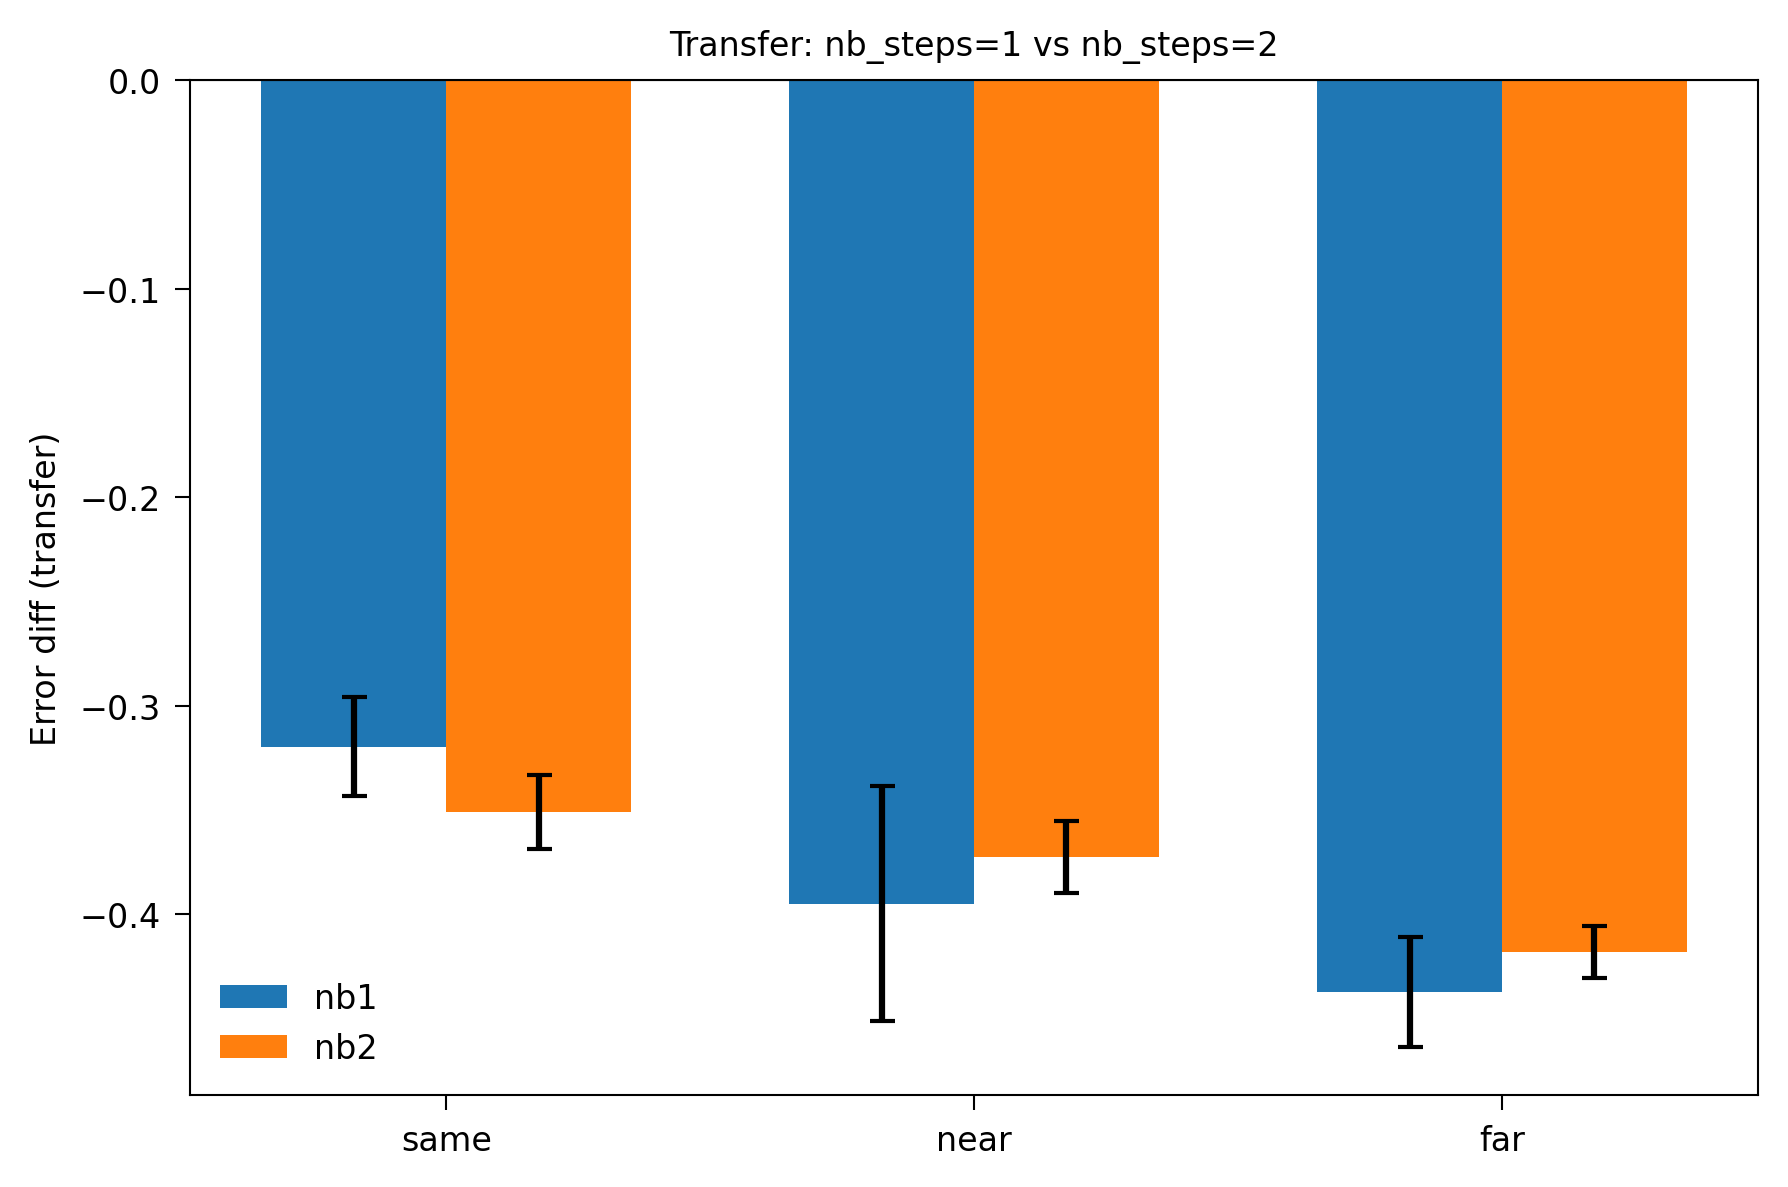

In [5]:
if transfer_all.empty:
    print("No data to plot. Run simulations and load cell first.")
else:
    agg = transfer_all.groupby(["run_label", "condition"], as_index=False)["error_diff"].agg(["mean", "sem"]).reset_index()
    fig, ax = plt.subplots(figsize=(6, 4))
    x = np.arange(len(condition_order))
    w = 0.35
    for i, run_label in enumerate(["nb1", "nb2"]):
        if run_label not in agg["run_label"].values:
            continue
        means = [agg[(agg["run_label"] == run_label) & (agg["condition"] == s)]["mean"].values for s in condition_order]
        means = [m[0] if len(m) else np.nan for m in means]
        sems = [agg[(agg["run_label"] == run_label) & (agg["condition"] == s)]["sem"].values for s in condition_order]
        sems = [s[0] if len(s) else 0 for s in sems]
        off = (i - 0.5) * w
        ax.bar(x + off, means, w, label=run_label, yerr=sems, capsize=3)
    ax.set_xticks(x)
    ax.set_xticklabels(condition_order)
    ax.set_ylabel("Error diff (transfer)")
    ax.legend()
    ax.axhline(0, color="k", linewidth=0.5)
    ax.set_title("Transfer: nb_steps=1 vs nb_steps=2")
    fig.tight_layout()
    plt.show()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

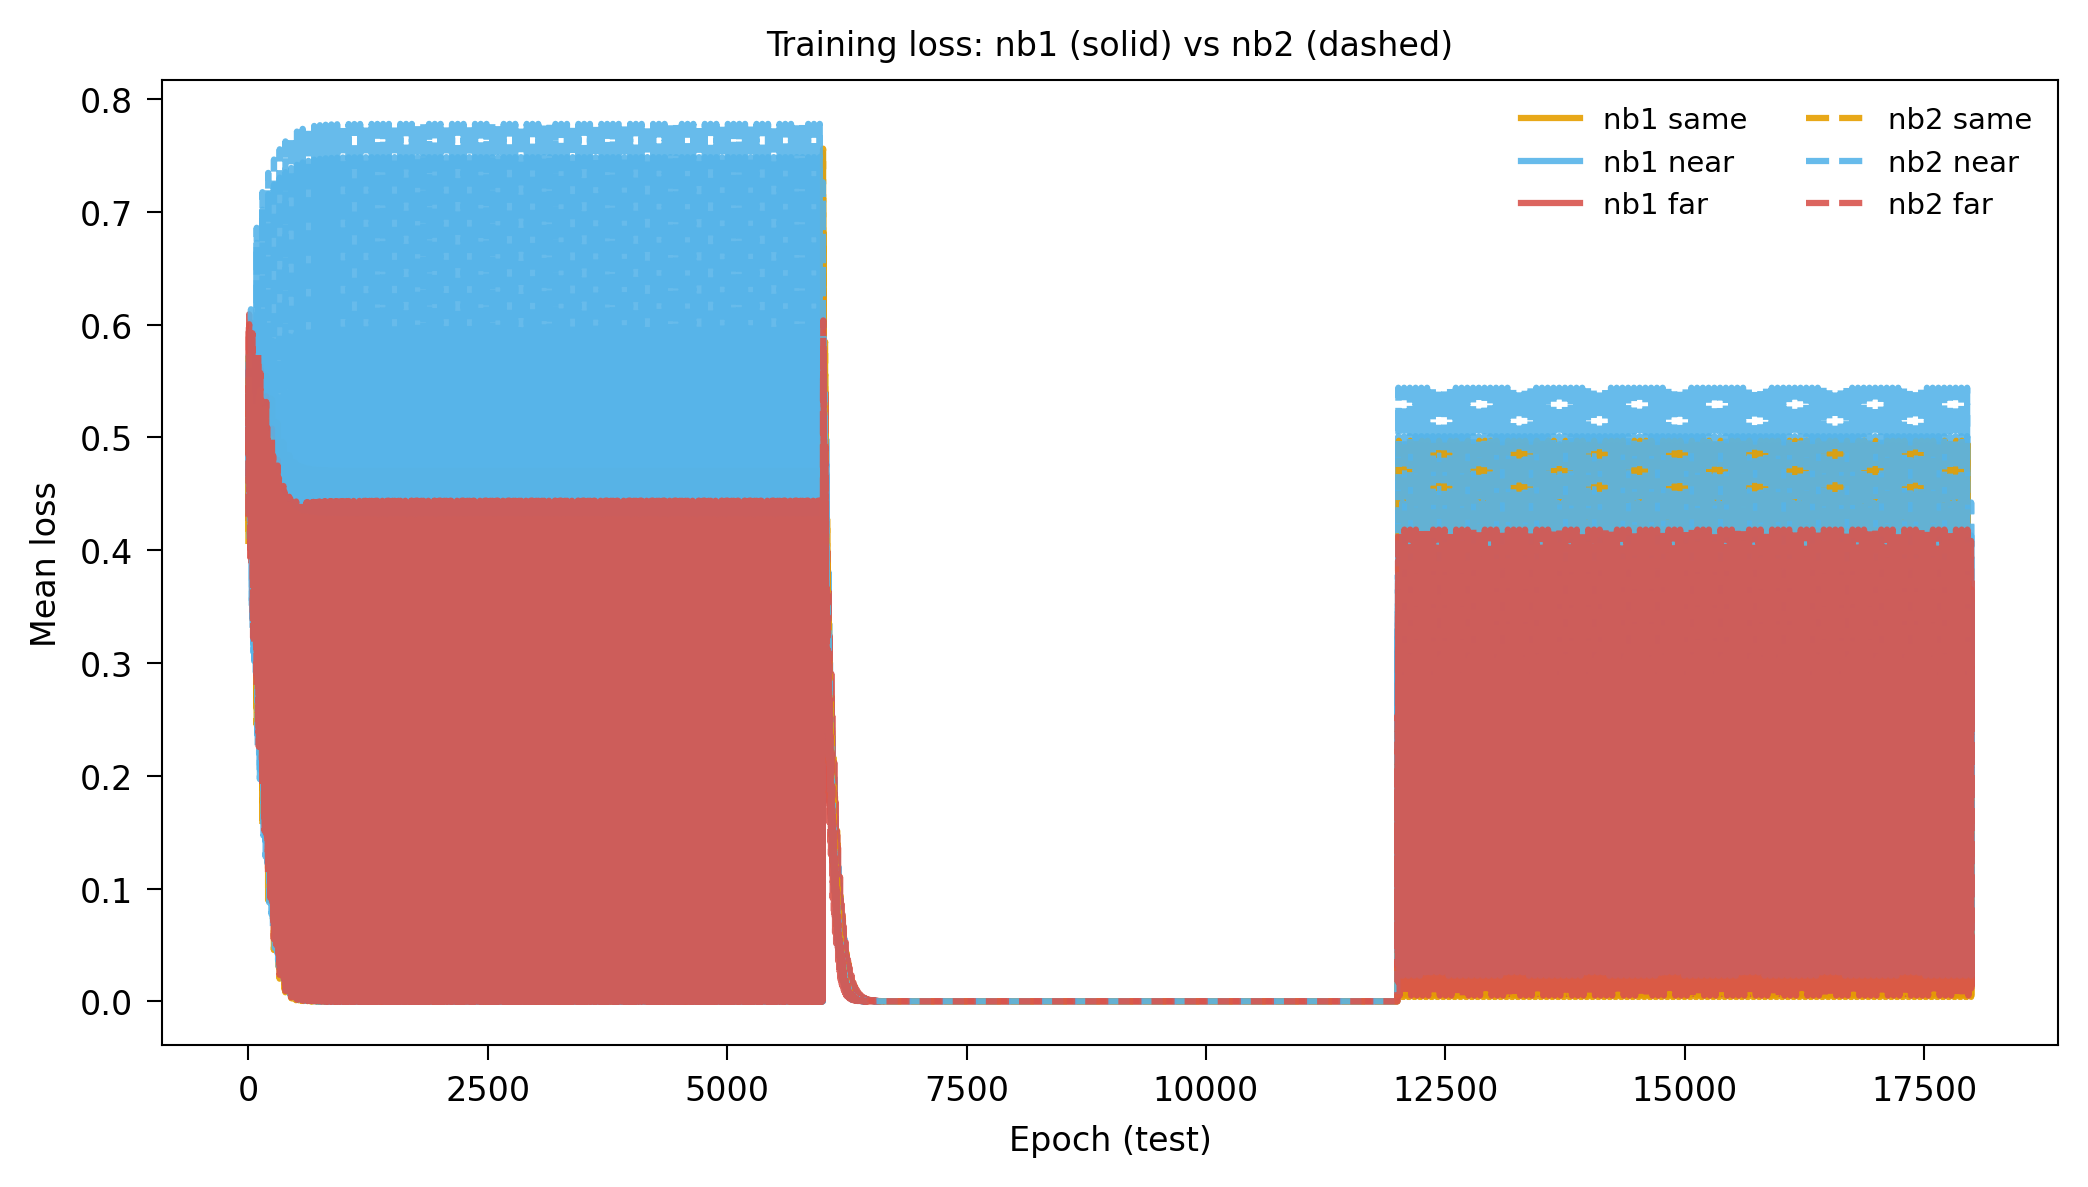

In [6]:
if loss_results:
    fig, ax = plt.subplots(figsize=(7, 4))
    for run_label in ["nb1", "nb2"]:
        if run_label not in loss_results:
            continue
        loss = loss_results[run_label]
        for s_idx, sched in enumerate(["same", "near", "far"]):
            mean_loss = loss[sched]["mean"]
            epochs = np.arange(len(mean_loss))
            ax.plot(epochs, mean_loss, label=f"{run_label} {sched}", color=schedule_colours[s_idx],
                    linestyle="-" if run_label == "nb1" else "--", alpha=0.9)
    ax.set_xlabel("Epoch (test)")
    ax.set_ylabel("Mean loss")
    ax.legend(ncol=2, fontsize=7)
    ax.set_title("Training loss: nb1 (solid) vs nb2 (dashed)")
    fig.tight_layout()
    plt.show()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

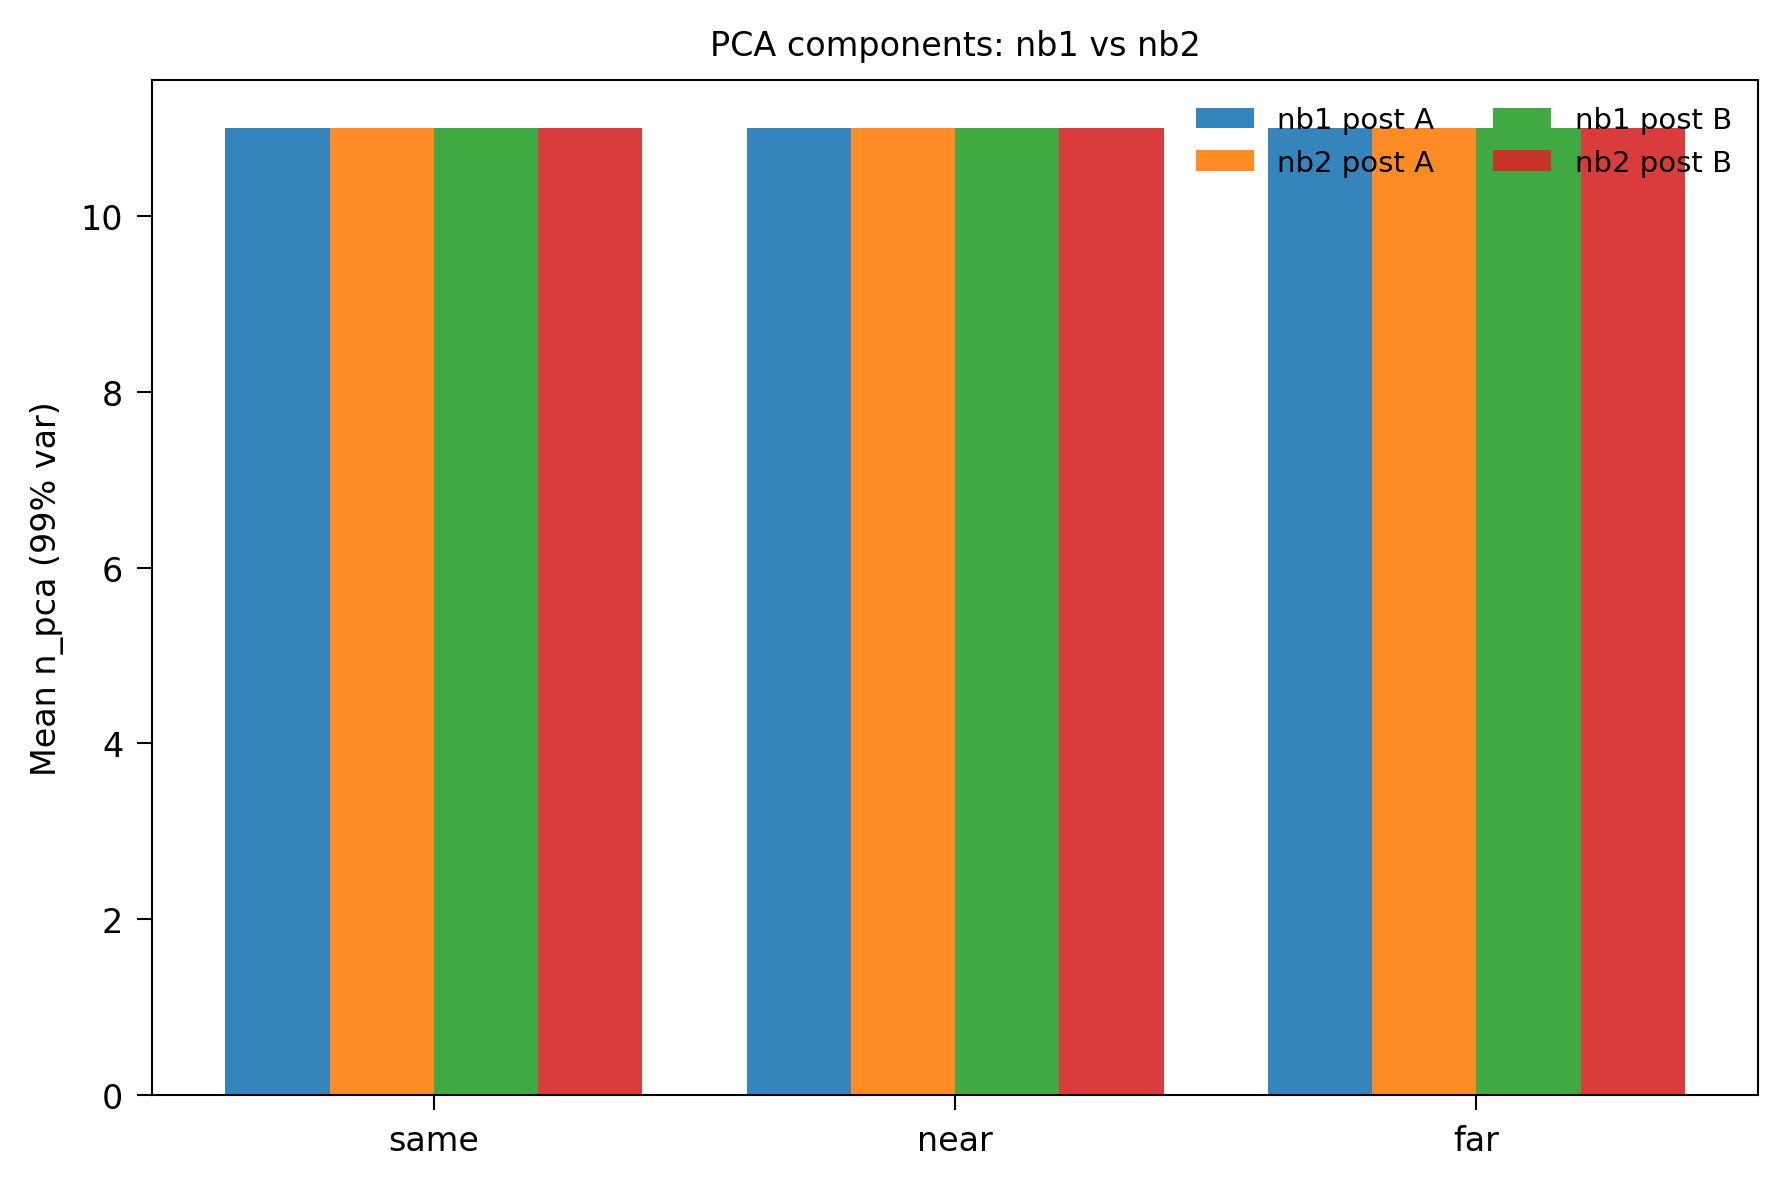

In [7]:
if not pca_all.empty:
    fig, ax = plt.subplots(figsize=(6, 4))
    pca_agg = pca_all.groupby(["run_label", "condition", "task"], as_index=False)["n_pca"].mean()
    x = np.arange(len(condition_order))
    w = 0.2
    for ti, task in enumerate(["post A", "post B"]):
        for ri, run_label in enumerate(["nb1", "nb2"]):
            sub = pca_agg[(pca_agg["run_label"] == run_label) & (pca_agg["task"] == task)]
            means = [sub[(sub["condition"] == s)]["n_pca"].values for s in condition_order]
            means = [float(m[0]) if len(m) else np.nan for m in means]
            off = (ti - 0.5) * 2 * w + (ri - 0.5) * w
            ax.bar(x + off, means, w, label=f"{run_label} {task}", alpha=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(condition_order)
    ax.set_ylabel("Mean n_pca (99% var)")
    ax.legend(ncol=2, fontsize=7)
    ax.set_title("PCA components: nb1 vs nb2")
    fig.tight_layout()
    plt.show()

TypeError: A single argument passed to legend() must be a list of labels, but found an Artist in there.

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

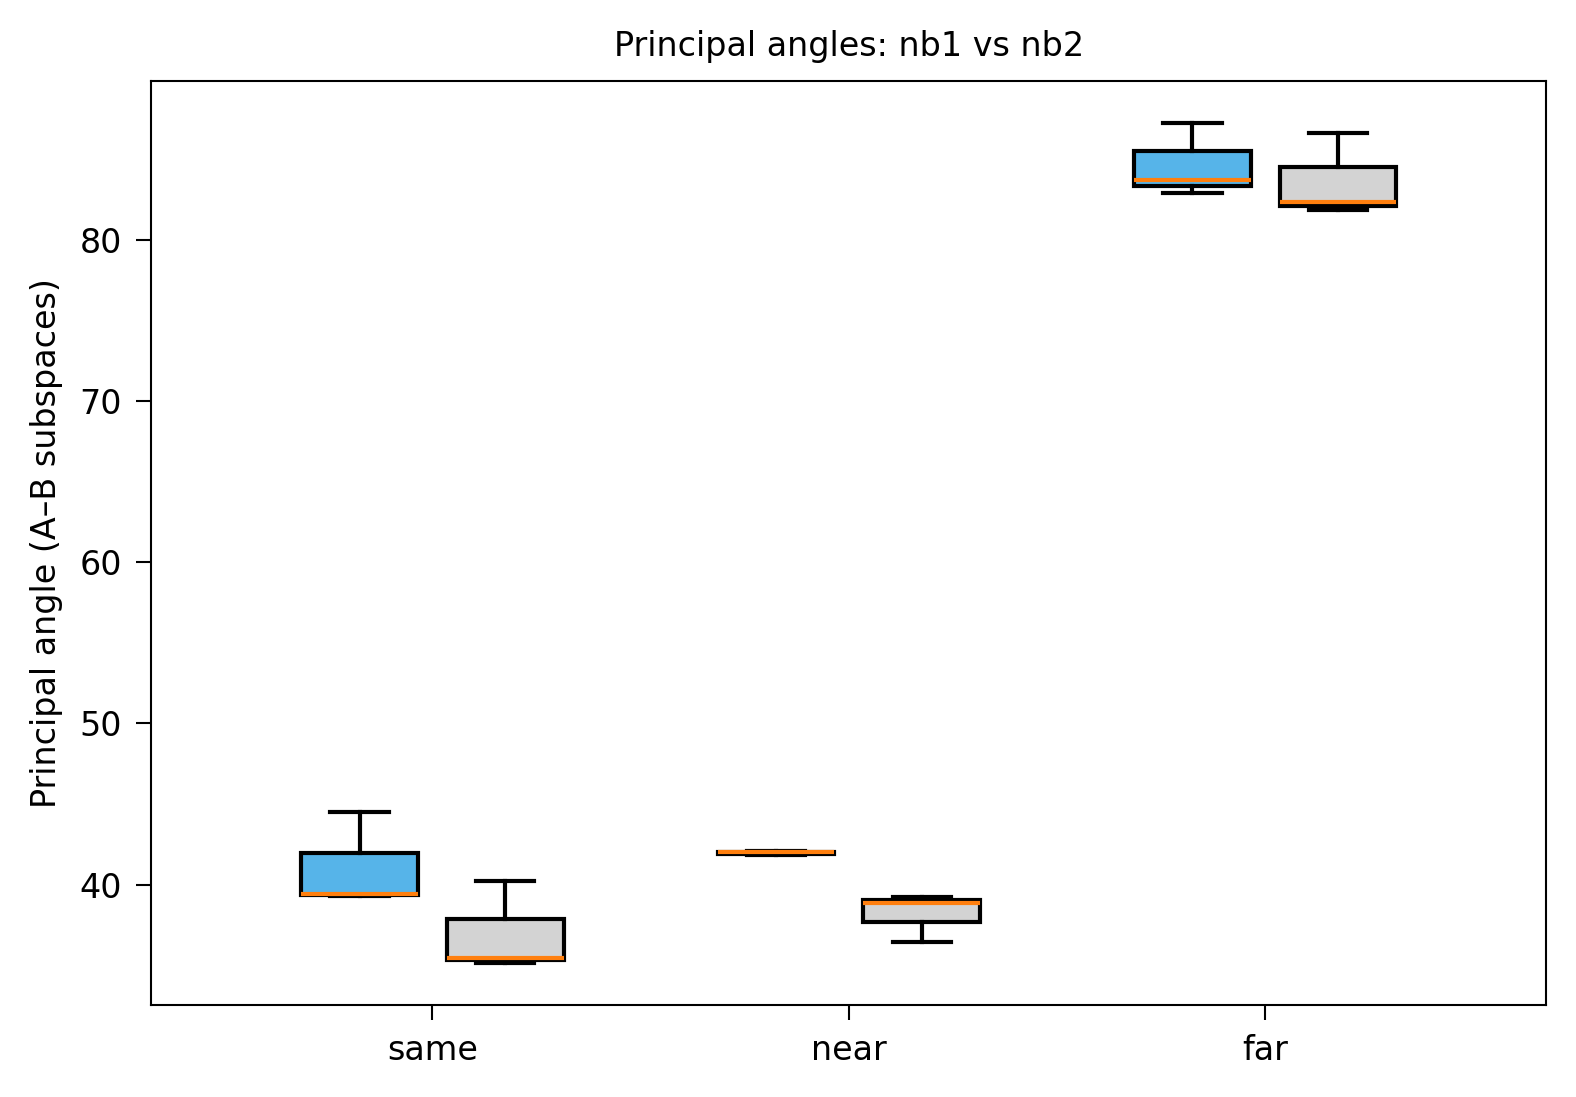

In [9]:
if not angles_all.empty:
    fig, ax = plt.subplots(figsize=(6, 4))
    positions = np.arange(len(condition_order))
    width = 0.35
    for ri, run_label in enumerate(["nb1", "nb2"]):
        sub = angles_all[angles_all["run_label"] == run_label]
        if sub.empty:
            continue
        data_by_cond = [sub[sub["condition"] == s]["principal_angle_between"].values for s in condition_order]
        data_by_cond = [d for d in data_by_cond if len(d) > 0]
        if not data_by_cond:
            continue
        pos = positions + (ri - 0.5) * width
        bp = ax.boxplot(data_by_cond, positions=pos, widths=width * 0.8, patch_artist=True)
        color = "#56B4E9" if run_label == "nb1" else "lightgray"
        for patch in bp["boxes"]:
            patch.set_facecolor(color)
    ax.set_xticks(positions)
    ax.set_xticklabels(condition_order)
    ax.set_ylabel("Principal angle (A–B subspaces)")
    ax.set_title("Principal angles: nb1 vs nb2")
    from matplotlib.patches import Patch
    legend_handles = [Patch(facecolor="#56B4E9", label="nb1"), Patch(facecolor="lightgray", label="nb2")]
    ax.legend(handles=legend_handles)
    fig.tight_layout()
    plt.show()

### 5b. Sanity: nb2 trajectory data

Check that nb2 run contains trajectory (or per-module) keys; optionally plot 2D PCA of one trajectory.

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

nb2 RNN-extra keys (trajectory/per_module): ['hiddens_per_module', 'hiddens_post_phase_0_trajectory', 'hiddens_post_phase_1_trajectory', 'hiddens_post_phase_2_trajectory', 'hiddens_post_phase_0_per_module', 'hiddens_post_phase_1_per_module', 'hiddens_post_phase_2_per_module']
  hiddens_post_phase_0_trajectory shape: (2, 12, 100)


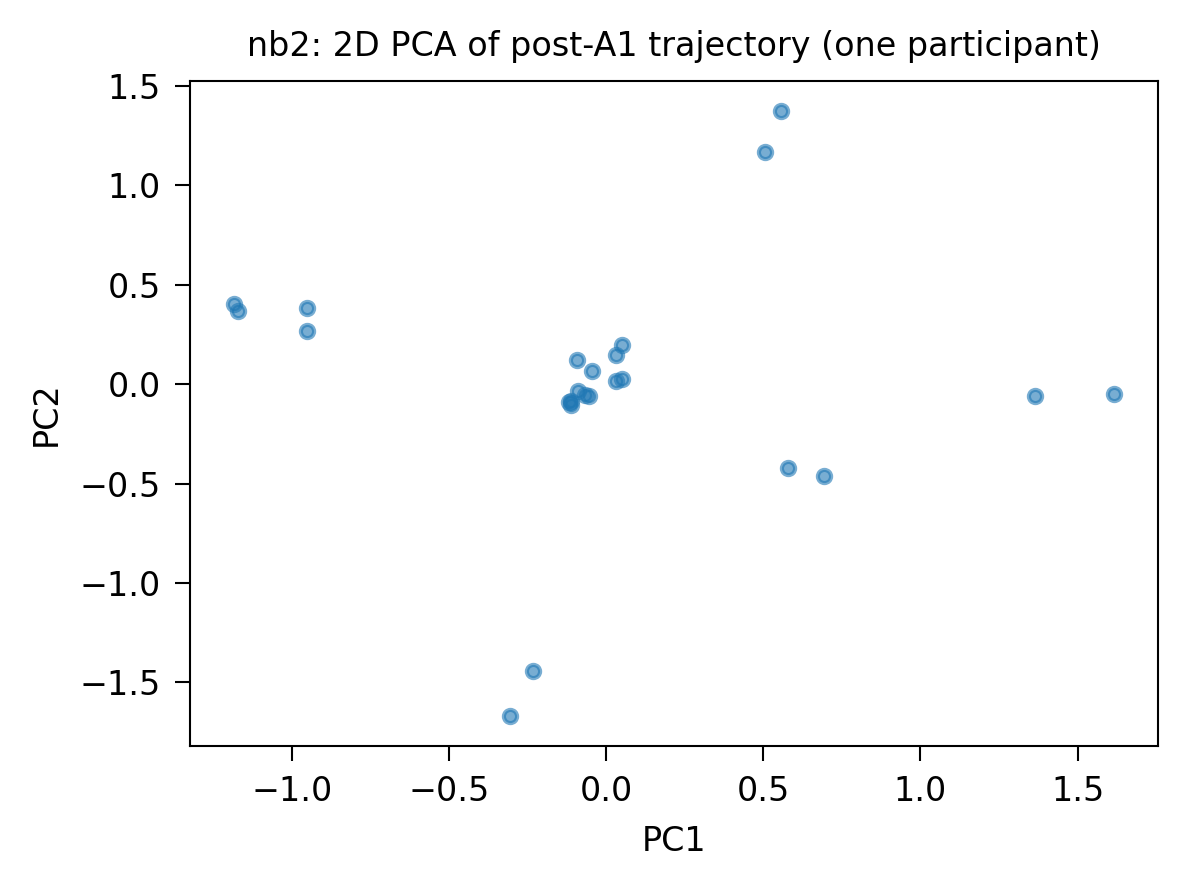

In [13]:
if "nb2" in all_ann_data and len(all_ann_data["nb2"]["same"]) > 0:
    sample = all_ann_data["nb2"]["same"][0]
    traj_keys = [k for k in sample.keys() if "trajectory" in k or "per_module" in k]
    print("nb2 RNN-extra keys (trajectory/per_module):", traj_keys)
    if "hiddens_post_phase_0_trajectory" in sample:
        traj = sample["hiddens_post_phase_0_trajectory"]
        print(f"  hiddens_post_phase_0_trajectory shape: {traj.shape}")
        if traj.size > 0 and traj.ndim >= 2:
            from sklearn.decomposition import PCA
            # (T, B, hidden) or (T, hidden) -> flatten to (n_steps, hidden)
            if traj.ndim == 3:
                T, B, H = traj.shape
                X = traj.reshape(T * B, H)
            else:
                X = np.asarray(traj)
            if X.shape[0] >= 2:
                pca = PCA(n_components=2).fit(X)
                proj = pca.transform(X)
                fig, ax = plt.subplots(figsize=(4, 3))
                ax.scatter(proj[:, 0], proj[:, 1], alpha=0.6, s=10)
                ax.set_xlabel("PC1")
                ax.set_ylabel("PC2")
                ax.set_title("nb2: 2D PCA of post-A1 trajectory (one participant)")
                fig.tight_layout()
                plt.show()
else:
    print("nb2 data not loaded or empty; skip trajectory check.")

## 6. Summary table

Per schedule: mean (SEM) transfer for nb1 and nb2; short interpretation.

In [14]:
if not transfer_all.empty:
    summary = transfer_all.groupby(["run_label", "condition"])["error_diff"].agg(["mean", "sem", "count"]).reset_index()
    summary["mean_sem"] = summary.apply(lambda r: f"{r['mean']:.4f} ({r['sem']:.4f})", axis=1)
    pivot = summary.pivot(index="condition", columns="run_label", values="mean_sem")
    pivot = pivot.reindex(condition_order)
    print("Transfer (error_diff): mean (SEM)")
    try:
        from IPython.display import display
        display(pivot)
    except ImportError:
        print(pivot.to_string())
    print("\nInterpretation: nb2 should show the same qualitative pattern as nb1 (e.g. more interference for far than near than same). "
          "Trajectory data is present only for nb2.")
else:
    print("No transfer data.")

Transfer (error_diff): mean (SEM)


run_label,nb1,nb2
condition,,
same,-0.3196 (0.0237),-0.3510 (0.0176)
near,-0.3948 (0.0563),-0.3726 (0.0173)
far,-0.4370 (0.0263),-0.4179 (0.0124)



Interpretation: nb2 should show the same qualitative pattern as nb1 (e.g. more interference for far than near than same). Trajectory data is present only for nb2.
